In [1]:
import phasr as phr
import numpy as np
import matplotlib.pyplot as plt
from phasr.dirac_solvers.post_processing.overlap_integrals import nabla_dot_plus, nabla_dot_minus
from phasr.physical_constants import masses
from scipy import integrate
from mpmath import diff
from IPython.display import display, Math
from collections import defaultdict
mmu=masses.mmu #MeV
hc=phr.constants.hc #MeV*fm
hbar=phr.constants.hbar #MeV*s
from scipy.special import spherical_jn, spherical_yn

def derivative(func,x,dx=1e-6):
    return (func(x+dx)-func(x-dx))/(2*dx)

In [2]:
# Load structure functions
AI_dict = phr.dirac_solvers.post_processing.correlation.prepare_results(Z=13,A=27,folder_path="./IMSRG_27Al(2)/",name='Al27_ab_initio',r_cut=6.)

Loaded datasets: ['dn2logo', 'n2losat']
data loaded from  ./tmp/nucleus_splines/charge_density_M0p_Al27_ab_initio_dn2logo_x=0.0-6.0-0.05.txt
data loaded from  ./tmp/nucleus_splines/charge_density_M0pm2_Al27_ab_initio_dn2logo_x=0.0-6.0-0.05.txt
data loaded from  ./tmp/nucleus_splines/charge_density_M0p2_Al27_ab_initio_dn2logo_x=0.0-6.0-0.05.txt
data loaded from  ./tmp/nucleus_splines/charge_density_laplace_M0p_Al27_ab_initio_dn2logo_x=0.0-6.6000000000000005-0.05.txt
data loaded from  ./tmp/nucleus_splines/charge_density_M0n_Al27_ab_initio_dn2logo_x=0.0-6.0-0.05.txt
data loaded from  ./tmp/nucleus_splines/charge_density_M0nm2_Al27_ab_initio_dn2logo_x=0.0-6.0-0.05.txt
data loaded from  ./tmp/nucleus_splines/charge_density_M0n2_Al27_ab_initio_dn2logo_x=0.0-6.0-0.05.txt
data loaded from  ./tmp/nucleus_splines/charge_density_laplace_M0n_Al27_ab_initio_dn2logo_x=0.0-6.6000000000000005-0.05.txt
data loaded from  ./tmp/nucleus_splines/charge_density_Phipp0p_Al27_ab_initio_dn2logo_x=0.0-6.0-0.05

In [3]:
# Iterate over nuclear structure model
for AI_model in AI_dict:
    nucleus=AI_dict[AI_model]['atom']

    # Calculate electron wavefunctions for ejected electron
    AI_dict[AI_model]['ge']={}
    AI_dict[AI_model]['fe']={}
    for kappa in np.arange(-1,-2*nucleus.spin-3,-1,dtype=int):
        continuumstates = phr.continuumstates(nucleus,kappa=kappa,energy=mmu,verbose=False,potential_precision=1e-6)
        continuumstates.solve_IVP()
        AI_dict[AI_model]['ge'][str(kappa)] = continuumstates.wavefct_g
        AI_dict[AI_model]['fe'][str(kappa)] = continuumstates.wavefct_f

    # Calculate muon wavefunctions for bound muon
    boundstates = phr.boundstates(nucleus,kappa=-1,lepton_mass=mmu, verbose=False,potential_precision=1e-6)
    AI_dict[AI_model]['gmu']=boundstates.wavefunction_g_1s12
    AI_dict[AI_model]['fmu']=boundstates.wavefunction_f_1s12

/tmp/ipykernel_7407/775185813.py:20: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return integrate.quad(lambda x: 4*np.pi*leptonic_part(x,kappa,type,AI_model)*spherical_jn(L,q*x/hc),0,bound,epsrel=1e-4)[0]


Text(0, 0.5, 'Leptonic FF')

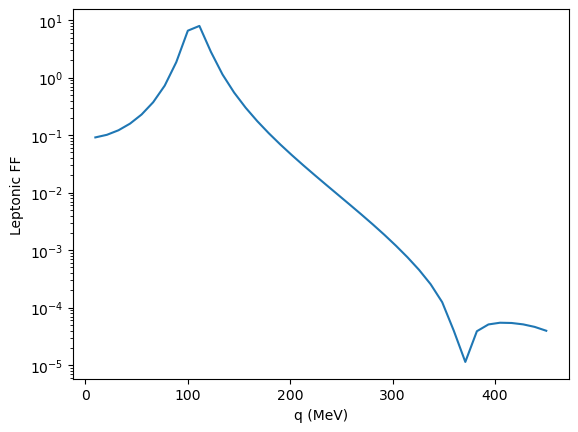

In [4]:
# Step 1: Create leptonic combinations

def leptonic_part(x,kappa,type='g',AI_model=AI_model):
    if type=='gg':
        return AI_dict[AI_model]['ge'][str(kappa)](x)*AI_dict[AI_model]['gmu'](x)
    if type=='gf':
        return AI_dict[AI_model]['ge'][str(kappa)](x)*AI_dict[AI_model]['fmu'](x)
    if type=='fg':
        return AI_dict[AI_model]['fe'][str(kappa)](x)*AI_dict[AI_model]['gmu'](x)
    if type=='ff':
        return AI_dict[AI_model]['fe'][str(kappa)](x)*AI_dict[AI_model]['fmu'](x)


# Calculate momentum FFs
q=np.linspace(0,1000,200) #MeV
def leptonic_part_FF(q,kappa,L,type='g',AI_model=AI_model):
    Z=AI_dict[AI_model]['atom'].Z
    coeff=(mmu/hc)/(np.sqrt(1+(137./Z)**2))
    bound=max(50.,12/coeff)
    return integrate.quad(lambda x: 4*np.pi*leptonic_part(x,kappa,type,AI_model)*spherical_jn(L,q*x/hc),0,bound,epsrel=1e-4)[0]
leptonic_part_FF=np.vectorize(leptonic_part_FF)

q=np.linspace(10,450,40) #MeV
plt.plot(q,np.abs(leptonic_part_FF(q,-1,0,'gg','dn2logo')),label='gg')
plt.yscale('log')
plt.xlabel('q (MeV)')
plt.ylabel('Leptonic FF')